In [122]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [123]:
df = pd.read_csv("fifa2026_player_performance.csv")
df.head()

,player_name,nationality,club,position,age,market_value_eur_m,season,competition,match_id,minutes_played,...,assists,shots_on_target,pass_accuracy_pct,tackles,distance_covered_km,match_rating,yellow_card,red_card,fouls_committed,injured_flag
0,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,11.01,2025/26,Champions League,111378,53,...,0,0,NaN,2,5.79,5.8,False,False,0,False
1,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.69,2025/26,Champions League,111379,63,...,0,0,85.2,2,10.31,6.9,False,False,3,False
2,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.61,2025/26,Champions League,111380,90,...,0,0,94.8,4,14.50,7.5,False,False,0,False
3,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,11.26,2025/26,Champions League,111381,12,...,0,0,74.9,1,0.91,4.0,False,False,3,False
4,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.50,2025/26,Champions League,111382,39,...,0,0,78.0,3,4.36,5.0,False,False,2,False


In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13397 entries, 0 to 13396
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_name          13397 non-null  str    
 1   nationality          13397 non-null  str    
 2   club                 13397 non-null  str    
 3   position             13397 non-null  str    
 4   age                  13397 non-null  int64  
 5   market_value_eur_m   13127 non-null  float64
 6   season               13397 non-null  str    
 7   competition          13397 non-null  str    
 8   match_id             13397 non-null  int64  
 9   minutes_played       13397 non-null  int64  
 10  goals                13397 non-null  int64  
 11  assists              13397 non-null  int64  
 12  shots_on_target      13397 non-null  int64  
 13  pass_accuracy_pct    12590 non-null  float64
 14  tackles              13397 non-null  int64  
 15  distance_covered_km  12718 non-null  float64
 1

In [125]:
df.isnull().sum()

player_name              0
nationality              0
club                     0
position                 0
age                      0
market_value_eur_m     270
season                   0
competition              0
match_id                 0
minutes_played           0
goals                    0
assists                  0
shots_on_target          0
pass_accuracy_pct      807
tackles                  0
distance_covered_km    679
match_rating             0
yellow_card              0
red_card                 0
fouls_committed          0
injured_flag             0
dtype: int64

In [126]:
df.shape

(13397, 21)

In [127]:
ct = ColumnTransformer(
    transformers = [
        ("pac", SimpleImputer(strategy="median",), ["pass_accuracy_pct",]),
        ("dck", SimpleImputer(strategy="median"), ["distance_covered_km",],),
        ("mven", SimpleImputer(strategy="median"), ["market_value_eur_m",],),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False, 
).set_output(transform='pandas')

df = ct.fit_transform(df)
df

,pass_accuracy_pct,distance_covered_km,market_value_eur_m,player_name,nationality,club,position,age,season,competition,...,minutes_played,goals,assists,shots_on_target,tackles,match_rating,yellow_card,red_card,fouls_committed,injured_flag
0,77.3,5.79,11.01,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,...,53,0,0,0,2,5.8,False,False,0,False
1,85.2,10.31,10.69,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,...,63,0,0,0,2,6.9,False,False,3,False
2,94.8,14.50,10.61,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,...,90,0,0,0,4,7.5,False,False,0,False
3,74.9,0.91,11.26,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,...,12,0,0,0,1,4.0,False,False,3,False
4,78.0,4.36,10.50,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,...,39,0,0,0,3,5.0,False,False,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13392,71.1,5.52,25.30,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,...,71,0,0,0,1,5.9,False,False,2,False
13393,67.8,0.53,12.57,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,...,6,0,0,1,0,4.0,False,False,2,False
13394,49.1,0.69,26.48,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,...,20,0,0,1,2,4.0,False,False,0,False
13395,46.8,6.37,25.89,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,...,59,0,0,0,1,5.7,False,False,0,False


In [128]:
df.isnull().sum()

pass_accuracy_pct      0
distance_covered_km    0
market_value_eur_m     0
player_name            0
nationality            0
club                   0
position               0
age                    0
season                 0
competition            0
match_id               0
minutes_played         0
goals                  0
assists                0
shots_on_target        0
tackles                0
match_rating           0
yellow_card            0
red_card               0
fouls_committed        0
injured_flag           0
dtype: int64

In [129]:
df['high_performer'] = df['match_rating'].apply(lambda x: 1 if x >= 7.0 else 0)
df.head()
y = df['high_performer']

In [130]:
df = df.drop(columns=['player_name','match_id'])
df

,pass_accuracy_pct,distance_covered_km,market_value_eur_m,nationality,club,position,age,season,competition,minutes_played,goals,assists,shots_on_target,tackles,match_rating,yellow_card,red_card,fouls_committed,injured_flag,high_performer
0,77.3,5.79,11.01,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,53,0,0,0,2,5.8,False,False,0,False,0
1,85.2,10.31,10.69,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,63,0,0,0,2,6.9,False,False,3,False,0
2,94.8,14.50,10.61,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,90,0,0,0,4,7.5,False,False,0,False,1
3,74.9,0.91,11.26,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,12,0,0,0,1,4.0,False,False,3,False,0
4,78.0,4.36,10.50,Morocco,Paris Saint-Germain,RB,21,2025/26,Champions League,39,0,0,0,3,5.0,False,False,2,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13392,71.1,5.52,25.30,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,71,0,0,0,1,5.9,False,False,2,False,0
13393,67.8,0.53,12.57,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,6,0,0,1,0,4.0,False,False,2,False,0
13394,49.1,0.69,26.48,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,20,0,0,1,2,4.0,False,False,0,False,0
13395,46.8,6.37,25.89,Mali,Tottenham Hotspur,CDM,39,2025/26,World Cup Qualifiers,59,0,0,0,1,5.7,False,False,0,False,0


In [131]:
from sklearn.preprocessing import LabelEncoder
labelencoder_X = LabelEncoder()
df["position"] = labelencoder_X.fit_transform(df['position'])

In [132]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = ['nationality', 'club', 'season', 'competition']

preprocessor = ColumnTransformer(
    transformers=[
        ("num_col", StandardScaler(), num_cols),
        ("cat_col", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
).set_output(transform='pandas')

In [133]:
df = preprocessor.fit_transform(df)
df.head()

,pass_accuracy_pct,distance_covered_km,market_value_eur_m,position,age,minutes_played,goals,assists,shots_on_target,tackles,...,club_West Ham United,season_2025/26,competition_Champions League,competition_Domestic Cup,competition_FIFA World Cup 2026,competition_League,competition_World Cup Qualifiers,yellow_card,red_card,injured_flag
0,0.148299,-0.191018,-0.406575,0.738219,-1.130209,-0.253074,-0.373968,-0.344872,-0.469708,0.747607,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
1,0.717007,1.059422,-0.417903,0.738219,-1.130209,0.108630,-0.373968,-0.344872,-0.469708,0.747607,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
2,1.408096,2.218569,-0.420736,0.738219,-1.130209,1.085229,-0.373968,-0.344872,-0.469708,2.214677,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
3,-0.024473,-1.541052,-0.397724,0.738219,-1.130209,-1.736058,-0.373968,-0.344872,-0.469708,0.014072,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
4,0.198691,-0.586622,-0.424630,0.738219,-1.130209,-0.759459,-0.373968,-0.344872,-0.469708,1.481142,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False


In [134]:
X= df.drop(columns=['high_performer','match_rating'])

In [135]:
X.head()

,pass_accuracy_pct,distance_covered_km,market_value_eur_m,position,age,minutes_played,goals,assists,shots_on_target,tackles,...,club_West Ham United,season_2025/26,competition_Champions League,competition_Domestic Cup,competition_FIFA World Cup 2026,competition_League,competition_World Cup Qualifiers,yellow_card,red_card,injured_flag
0,0.148299,-0.191018,-0.406575,0.738219,-1.130209,-0.253074,-0.373968,-0.344872,-0.469708,0.747607,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
1,0.717007,1.059422,-0.417903,0.738219,-1.130209,0.108630,-0.373968,-0.344872,-0.469708,0.747607,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
2,1.408096,2.218569,-0.420736,0.738219,-1.130209,1.085229,-0.373968,-0.344872,-0.469708,2.214677,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
3,-0.024473,-1.541052,-0.397724,0.738219,-1.130209,-1.736058,-0.373968,-0.344872,-0.469708,0.014072,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False
4,0.198691,-0.586622,-0.424630,0.738219,-1.130209,-0.759459,-0.373968,-0.344872,-0.469708,1.481142,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,False,False,False


In [136]:
y

0        0
1        0
2        1
3        0
4        0
        ..
13392    0
13393    0
13394    0
13395    0
13396    0
Name: high_performer, Length: 13397, dtype: int64

In [137]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 13397 entries, 0 to 13396
Columns: 108 entries, pass_accuracy_pct to injured_flag
dtypes: bool(3), float64(105)
memory usage: 10.8 MB


In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [139]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [140]:
y_pred = classifier.predict(X_test)

In [141]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[1828  136]
 [ 134  582]]


In [142]:
from sklearn.metrics import accuracy_score

print("Accuracy Score : ", accuracy_score(y_test, y_pred))

Accuracy Score :  0.8992537313432836


In [143]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1964
           1       0.81      0.81      0.81       716

    accuracy                           0.90      2680
   macro avg       0.87      0.87      0.87      2680
weighted avg       0.90      0.90      0.90      2680



In [144]:
from sklearn.model_selection import KFold
kfold_validation = KFold(5)
model = LogisticRegression()

In [145]:
from sklearn.model_selection import cross_val_score

result = cross_val_score(model, X, y, cv=kfold_validation)
print(result)

[0.90634328 0.89402985 0.90220231 0.88316536 0.90892124]


In [146]:
k_accuracy = np.mean(result)
print(k_accuracy)
print("mean accuracy :",np.mean(result))

0.8989324096204309
mean accuracy : 0.8989324096204309


In [147]:
y_pred = model.fit(X_test,y_test)

In [148]:
from sklearn.metrics import roc_curve, auc

In [149]:
y_pred_logistic = classifier.decision_function(X_test)
print(y_pred_logistic)

[ 2.73222663 -1.07383869 -1.79662865 ... -6.53441936 -6.83519874
 -2.62266429]


In [150]:
logistic_fpr, logistic_tpr, threshold = roc_curve(y_test, y_pred_logistic)
auc_logistic = auc(logistic_fpr, logistic_tpr)
print(auc_logistic)

0.9601763303712637


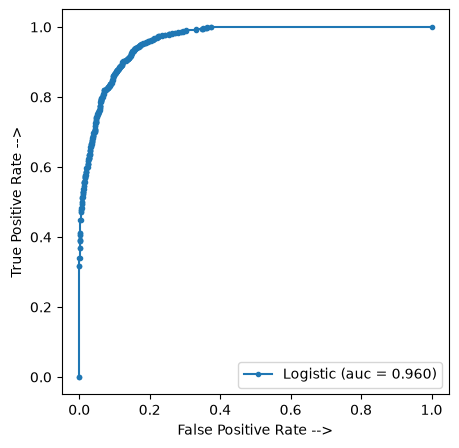

In [151]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.plot(
    logistic_fpr,
    logistic_tpr,
    marker=".",
    label="Logistic (auc = %0.3f)" % auc_logistic,
)
plt.xlabel("False Positive Rate -->")
plt.ylabel("True Positive Rate -->")
plt.legend(loc="lower right")
plt.show()